# CME Futures: Feature Engineering

A futures panel offers something an equity panel does not: the price of the same commodity for
delivery at several different dates, quoted side by side. That set of prices is the **term
structure**, and the gap between the nearest contract - the **front month** - and the one behind
it is the **carry**. Carry is knowable at the moment a position is decided rather than inferred
from past returns. This notebook builds it, and the momentum, volatility and calendar families it
is read against, states what window and what delay each one carries, and shows that none of them
reads a settlement dated at or after the decision.

## Learning objectives

- Build carry and curve shape from two and three contracts quoted on the same date, and see why
  that spread needs the prices the exchange actually settled while every return in the same
  notebook needs the roll-adjusted ones
- Write down how many past sessions each feature family reads, and how long it waits for its
  inputs to be published, before writing the code that computes it
- Rank products within one decision date **and** one contract position, so a front-month carry is
  never compared against a deferred-month one
- Rebuild the whole matrix with the late sessions withheld and check every value agrees, which is
  what separates a trailing statistic from one fitted over the whole sample

## Book reference, prerequisites and artifacts

Chapter 8, Sections 8.1-8.6. Reads session-aligned daily settlement bars for three tenors per
product via `load_cme_futures()`, and `config/setup.yaml`. Writes `features/financial.parquet`
with a `.digest.json` sidecar, read by [`05_evaluation`](05_evaluation.ipynb), which tests fold
by fold whether any of it predicts, and by the modelling notebooks from
[`06_linear`](06_linear.ipynb) onward, which join it with the labels into one training matrix.
[`04_model_based_features`](04_model_based_features.ipynb) works from the same settlement bars
rather than from this file, and the two feature sets meet at that modelling stage.

In [1]:
"""CME Futures: Feature Engineering."""

import warnings
from datetime import date

import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.engineer.features.momentum import rsi
from ml4t.engineer.features.regime import variance_ratio
from ml4t.engineer.features.volatility import yang_zhang_volatility
from plotly.subplots import make_subplots

from case_studies.utils.artifact_digest import value_digest, write_artifact
from case_studies.utils.backtest_loaders import resolve_rebalance_timestamps
from case_studies.utils.feature_engineering import (
    EPS,
    assert_values_agree,
    assign_families,
    cross_sectional_percentile,
    families_from_config,
    family_coverage,
    momentum_volatility_block,
    plot_coverage_through_time,
    plot_cross_sectional_dispersion,
    plot_feature_distributions,
    plot_persistence,
    plot_redundancy_clusters,
    plot_timing_contract,
    register_frame,
    rolling_zscore,
    trailing_return,
    warmup_audit,
)
from data import load_cme_futures
from utils.artifact_specs import resolve_label_horizon
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, style_subplot_titles

warnings.filterwarnings("ignore")

CASE_DIR = get_case_study_dir("cme_futures")
FEATURES_DIR = CASE_DIR / "features"

`START_DATE` is the first session the panel is built from. Left unset, it takes the whole
history the loader has; setting it to a date shortens the window, which is what to change for
a quick pass over a few recent years rather than the full sample.

In [2]:
START_DATE = None

## Configuration

Every window, the ranked-column mapping, the composite definitions, the sector map, the decision
horizon and the holdout boundary are declared in `config/setup.yaml` and bound here, so that the
register, the warmup assertion and the timing figure all read one set of numbers.

Two of those settings decide how the rest of the notebook is read. The **decision cycle** is how
many settlement sessions pass between one rebalance and the next, and it sets how far the
persistence figure in Section F has to look: a feature whose ordering has decayed before the
next rebalance cannot be traded at that cadence however well it predicts on the day it is
computed. The **holdout** is the block of late sessions no feature selection may read; Section D
rebuilds the whole matrix without it to show that nothing here depends on having seen it.

In [3]:
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
FEATURES = setup["features"]
FAMILIES = families_from_config(setup)
WINDOWS = FEATURES["windows"]
RANKED = FEATURES["ranked"]
LEVEL = FEATURES["thresholds"]
SECTOR = {p: g for g, ps in setup["universe"]["product_groups"].items() for p in ps}
SEASONAL = list(FEATURES["seasonal_sectors"])
PERIODS_PER_YEAR = setup["evaluation"]["periods_per_year"]
DECISION_CYCLE = int(
    resolve_label_horizon("cme_futures", setup["labels"]["primary"], setup).rstrip("Dd")
)
HOLDOUT_START = date.fromisoformat(setup["evaluation"]["holdout_start"])
HOLDOUT_END = date.fromisoformat(setup["evaluation"]["holdout_end"])

# The panel key, and the partition every cross-sectional statistic is taken over.
ENTITY = ["product", "position"]
PANEL_KEY = ["product", "position", "timestamp"]
WITHIN_DATE = ["timestamp", "position"]

print(f"{len(FAMILIES)} feature families declared, {len(RANKED)} of their levels also ranked")
print(f"Decision cycle {DECISION_CYCLE} settlement sessions, so the strategy rebalances weekly")
print(f"Holdout {HOLDOUT_START} to {HOLDOUT_END}, which no selection in this notebook may read")

8 feature families declared, 11 of their levels also ranked
Decision cycle 5 settlement sessions, so the strategy rebalances weekly
Holdout 2024-01-01 to 2025-12-31, which no selection in this notebook may read


## A. What the thesis says should carry information

The hypothesis is cross-sectional and it is about the shape of the curve: among 30 CME products
spanning equity index, rates, energy, metals, currencies, grains and livestock, the ones whose
near contract trades above the deferred one earn the roll that shape implies, and go on earning
it over the following week. Three things follow.

The **signal** is carry, and it is the one family here that is not a function of past returns.
It is quoted directly, so it needs no lookback at all - the smoothing, the z-score and the change
in carry are there to say whether today's spread is unusual *for this product*, which is a
different claim from the spread being wide.

The **conditioning** is momentum and volatility. Carry and trend are separate premia in the
futures literature, so the matrix carries returns at four horizons, their risk-adjusted twins,
the dispersion those are earned against, and whether the market is trending or reverting. The
calendar families rank nothing: they say which part of the year a grain or a heating-fuel curve
is being read in, which is what the register's `role` column records and what no assertion can
recover from the values.

The **frame** is what makes this case study different from the panel ones. Three tenors trade per
product-date, and a front-month carry and a deferred-month carry are not the same quantity, so
every percentile below is taken within a date **and** a contract position. Ranking across
positions would put ES front month and ES third month in one ordering and call the difference
information.

The register is declared in `config/setup.yaml`, one row per family. Every lag in it is zero:
settlement prices are published at the close of the session they are dated, and the decision is
taken at Friday's close, so no family here waits for an input to be released.

In [4]:
register_frame(FAMILIES).select(
    ["family", "role", "inputs", "lookback (bars)", "lag (bars)", "frame"]
)

family,role,inputs,lookback (bars),lag (bars),frame
str,str,str,i64,i64,str
"""term structure""","""signal""","""unadjusted front, second and t…",146,0,"""term structure"""
"""momentum""","""signal""","""roll-adjusted settlement price""",252,0,"""time series"""
"""risk-adjusted momentum""","""signal""","""log return""",252,0,"""time series"""
"""volatility and regime""","""state""","""OHLC settlement bars, log retu…",126,0,"""time series"""
"""trend and range""","""signal""","""roll-adjusted settlement price""",252,0,"""time series"""
"""calendar and season""","""state""","""the session date and the produ…",1,0,"""calendar"""
"""cross-sectional position""","""signal""","""the levels this register's oth…",252,0,"""cross-section"""
"""composite""","""signal""","""the percentiles of the cross-s…",252,0,"""cross-section"""


## B. Inputs and their observability

Each row is one product, one contract position and one session. Position 0 is the front month,
1 the second, 2 the third. Two price series arrive per row and they answer different questions.
`adj_close` is roll-adjusted, so a return spans a roll without the jump the contract change would
otherwise put there; `raw_close` is what the exchange settled, so a spread between two tenors
measures today's curve rather than the roll history baked into each adjusted series.

A settlement at or below zero is not a price a ratio can be taken against. WTI settled negative on
2020-04-20, and one such row otherwise propagates through every window that contains it as a
return of the wrong sign and a volatility of the wrong size. Nulling it once, here, is the single
data policy the rest of the notebook inherits.

In [5]:
PRICES = ["adj_open", "adj_high", "adj_low", "adj_close", "raw_close"]
bars = (
    load_cme_futures()
    .rename({"session_date": "timestamp", "tenor": "position"})
    .with_columns(pl.when(pl.col(c) > 0).then(pl.col(c)).otherwise(None).alias(c) for c in PRICES)
    .sort([*ENTITY, "timestamp"])
)
if START_DATE is not None:
    bars = bars.filter(pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())

print(f"{len(bars):,} bars over {bars['product'].n_unique()} products at 3 contract positions")
print(f"{bars['timestamp'].min()} to {bars['timestamp'].max()}")

312,859 bars over 30 products at 3 contract positions
2011-01-03 to 2025-12-31


The universe is worth looking at before anything is computed from it, because the
cross-sectional families below rank these thirty products against each other on every date. The
sector groups are the ones declared in `config/setup.yaml`, and the last column is the median
number of front-month contracts changing hands in a session.

Two things in it matter downstream. The seven sectors are of unequal size, from three products
to six, which is what makes the within-sector ranking in C.5 a coarse statistic. And liquidity
is not remotely uniform: the Treasury and equity-index curves trade in hundreds of thousands of
contracts a session where the livestock curves trade in tens of thousands, so a ranking that
treats all thirty as equally fillable is an assumption the cost work in Chapter 18 has to test
rather than a fact this stage establishes.

In [6]:
(
    bars.filter(pl.col("position") == 0)
    .with_columns(pl.col("product").replace_strict(SECTOR, default="unknown").alias("sector"))
    .group_by("sector")
    .agg(
        pl.col("product").unique().sort().str.join(", ").alias("products"),
        pl.col("timestamp").min().alias("first session"),
        pl.col("timestamp").max().alias("last session"),
        pl.col("volume").median().cast(pl.Int64).alias("median front-month volume"),
    )
    .sort("median front-month volume", descending=True)
)

sector,products,first session,last session,median front-month volume
str,str,date,date,i64
"""treasuries""","""ZB, ZF, ZN, ZT""",2011-01-03,2025-12-31,480520
"""equity_index""","""ES, NQ, RTY, YM""",2011-01-03,2025-12-31,248520
"""currencies""","""6A, 6B, 6C, 6E, 6J, 6S""",2011-01-03,2025-12-31,86364
"""agriculture""","""ZC, ZL, ZM, ZS, ZW""",2011-01-03,2025-12-30,53133
"""energy""","""CL, HO, NG, RB""",2011-01-03,2025-12-31,51793
"""metals""","""GC, HG, PL, SI""",2011-01-03,2025-12-31,49046
"""livestock""","""GF, HE, LE""",2011-01-03,2025-12-30,12663


## C. Feature construction, one subsection per family

### C.1 Term structure

Carry is how far the front contract settles above the next one along, as a fraction of the front
price, scaled by twelve:

$$c_{p,t} = 12 \times \frac{F^{(0)}_{p,t} - F^{(1)}_{p,t}}{F^{(0)}_{p,t}}$$

where the superscript is the contract position, so $F^{(0)}$ is the front contract and
$F^{(1)}$ the next one along. It is positive in **backwardation**, where the near contract is
dearer than the deferred one, and negative in **contango**, where it is cheaper.

The twelve would turn a one-month spread into a yearly rate, and four of these thirty products -
the energy curves - do list a contract every month. The other twenty-six are on quarterly or
irregular cycles, so for them the twelve is a scale factor and not an annual rate. It is the
same constant for every product and every date, so it moves no ranking and no z-score; what it
does not give is a level comparable between an energy curve and a Treasury one, which is why
C.5 also ranks carry inside its own sector.

Curvature is the second difference across all three tenors: a curve can be in backwardation and
still be bent, and the two say different things about where the pressure on it sits. Both
quantities are one value per product-date, shared by the three positions, and both read
`raw_close` for the reason B gives.

The smoothing, z-score and change windows below span the sessions on which the curve was
actually quoted, not every session in the panel. A product-date where the second contract did
not trade has no carry at all, and keeping it as a gap would null the smoothed level for the
three weeks that follow it; the left join in `build_features` puts those dates back with a null
carry. The z-score is clipped at five standard deviations. It is carried as a level and never
ranked, so what the clip bounds is the number a model reads and the number the interaction score
in C.5 multiplies, in the weeks where a single settlement sends the ratio far out.

There is no library call for either quantity. `ml4t.engineer.features` covers statistics of a
single price series, and a term structure is a relation between contemporaneous series, so this
subsection is the one place in the notebook where the construction is local rather than
imported.

In [7]:
def term_structure(bars: pl.DataFrame) -> pl.DataFrame:
    """Carry, curvature, and how unusual each is for this product, per product-date."""
    smoothing = WINDOWS["carry_smoothing"]
    curve = (
        bars.filter(pl.col("position") <= 2)
        .pivot(on="position", index=["product", "timestamp"], values="raw_close")
        .rename({"0": "c0", "1": "c1", "2": "c2"})
        .sort(["product", "timestamp"])
        .with_columns(
            ((pl.col("c0") - pl.col("c1")) / pl.col("c0") * 12).alias("carry_pct"),
            ((pl.col("c0") - 2 * pl.col("c1") + pl.col("c2")) / pl.col("c1")).alias(
                "curve_curvature_norm"
            ),
        )
        .drop_nulls("carry_pct")
    )
    band = LEVEL["carry_regime_band"]
    curve = curve.with_columns(
        pl.col("carry_pct").rolling_mean(smoothing).over("product").alias("carry_21d"),
        pl.col("curve_curvature_norm")
        .rolling_mean(smoothing)
        .over("product")
        .alias(f"curvature_{smoothing}d"),
        pl.when(pl.col("carry_pct") > band)
        .then(1)
        .when(pl.col("carry_pct") < -band)
        .then(-1)
        .otherwise(0)
        .cast(pl.Int32)
        .alias("carry_regime_num"),
    )
    return curve.with_columns(
        *[
            (pl.col("carry_21d") - pl.col("carry_21d").shift(w).over("product")).alias(
                f"carry_momentum_{w}d"
            )
            for w in WINDOWS["carry_momentum"]
        ],
        *[
            rolling_zscore("carry_21d", w, "product").clip(-5.0, 5.0).alias(f"carry_zscore_{w}d")
            for w in WINDOWS["carry_zscore"]
        ],
    ).drop("c0", "c1", "c2")

### C.2 Momentum, risk-adjusted momentum and volatility

The trailing return, volatility and Sharpe block is the shared one, called here with this panel's
entity key so that a shift means "the previous session for this product at this contract
position" and never "the previous row in the file". A shared implementation is what keeps
`sharpe_126d` meaning one thing across the case studies: the mean log return over its own
dispersion, annualized, rather than a window return divided by a volatility of another window.

What stays local is specific to futures. Skip-month momentum runs from $t-252$ to $t-21$ and
divides prices rather than subtracting returns, because returns compound. Yang-Zhang is carried
beside the close-to-close estimator because an overnight gap in a futures contract is a real move
that a close-to-close estimator cannot see. The variance ratio says whether the recent path
trended or reverted, which is a statement about the regime rather than the level of risk.

The two ratios of volatility windows are capped at ten. A quiet stretch can put a near-zero
window in the denominator, and the cap bounds what that produces without discarding the row.

In [8]:
def price_features(bars: pl.DataFrame) -> pl.DataFrame:
    """Everything computed from one contract's own price history."""
    vol = WINDOWS["volatility"]
    horizons = WINDOWS["momentum"]
    vr = WINDOWS["variance_ratio"]
    df = momentum_volatility_block(
        bars,
        entity=ENTITY,
        price="adj_close",
        return_windows=horizons,
        volatility_windows=vol,
        periods_per_year=PERIODS_PER_YEAR,
    )
    held = pl.col("adj_close").shift(WINDOWS["skip_recent"]).over(ENTITY)
    start = pl.col("adj_close").shift(WINDOWS["skip_start"]).over(ENTITY)
    return df.with_columns(
        trailing_return("adj_close", WINDOWS["short_return"], ENTITY).alias("ret_5d"),
        (held / start.clip(lower_bound=EPS) - 1).alias("skip_month_mom"),
        (pl.col(f"vol_{vol[0]}d") / pl.col(f"vol_{vol[1]}d").clip(lower_bound=EPS))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_short"),
        (pl.col(f"vol_{vol[1]}d") / pl.col(f"vol_{vol[2]}d").clip(lower_bound=EPS))
        .clip(upper_bound=10.0)
        .alias("vol_ratio_medium"),
        yang_zhang_volatility(
            "adj_open",
            "adj_high",
            "adj_low",
            "adj_close",
            period=WINDOWS["yang_zhang"],
            annualize=True,
        )
        .over(ENTITY)
        .alias(f"vol_yz_{WINDOWS['yang_zhang']}d"),
        variance_ratio("adj_close", periods=[vr["horizon"]], window=vr["window"])[
            f"vr_{vr['horizon']}"
        ]
        .over(ENTITY)
        .alias(f"vr_{vr['window']}d"),
        *[
            pl.col(f"ret_{h}d").sign().cast(pl.Int32).alias(f"ts_mom_{h}d")
            for h in WINDOWS["trend_sign"]
        ],
    ).with_columns(
        (pl.col(f"ret_{a}d") - pl.col(f"ret_{b}d")).alias(f"mom_accel_{name}")
        for name, a, b in zip(("short", "medium", "long"), horizons[:-1], horizons[1:], strict=True)
    )

### C.3 Trend and range

Where a contract sits against its own moving averages and its own 52-week extremes. `rsi_14`
comes from `ml4t.engineer.features.momentum`, which applies Wilder's recursive smoothing to
prices; a simple moving average of the same gains and losses is a different oscillator under the
same name, and a reader carrying a column name between chapters is carrying a claim.

The library calls return NaN where their window has not filled, and polars treats NaN as a value
rather than as missing: a rank over such a column puts every warmup row at the top of the
cross-section. They are converted to nulls here, so the audit in D.2 and the percentiles in C.5
see the same missingness as the rest of the matrix.

In [9]:
LIBRARY_NAN = ["rsi_14", "vol_yz_21d", "vr_63d"]


def trend_and_range(df: pl.DataFrame) -> pl.DataFrame:
    """Price against its own moving averages, its extremes, and a bounded oscillator."""
    close = pl.col("adj_close")
    return df.with_columns(
        *[
            (close / close.rolling_mean(p).over(ENTITY)).alias(f"ma_ratio_{p}")
            for p in WINDOWS["moving_average"]
        ],
        (close / close.rolling_max(WINDOWS["high"]).over(ENTITY)).alias("dist_from_52w_high"),
        (close / close.rolling_min(WINDOWS["low"]).over(ENTITY)).alias("dist_from_6m_low"),
        rsi("adj_close", period=WINDOWS["rsi"]).over(ENTITY).alias(f"rsi_{WINDOWS['rsi']}"),
    ).with_columns(pl.col(LIBRARY_NAN).fill_nan(None))

### C.4 Calendar and season

Month is encoded as a point on a circle rather than as an integer, so December sits next to
January instead of eleven units away from it. The seasonal flag and the sector map are read from
the configuration's own product groups, which is where the universe is defined; the roll-week
flag marks the last calendar week of the month, when CME contracts of the monthly cycle are
rolling and the front month is thinning out.

In [10]:
def calendar_features(df: pl.DataFrame) -> pl.DataFrame:
    """Where in the year, and in the roll cycle, each session sits."""
    angle = 2 * np.pi * pl.col("timestamp").dt.month().cast(pl.Float64) / 12
    sector = pl.col("product").replace_strict(SECTOR, default="unknown")
    return df.with_columns(
        angle.sin().alias("month_sin"),
        angle.cos().alias("month_cos"),
        (pl.col("timestamp").dt.ordinal_day().cast(pl.Float64) / 365.25).alias("day_of_year_norm"),
        pl.col("timestamp").dt.quarter().cast(pl.Float64).alias("quarter"),
        sector.is_in(SEASONAL).cast(pl.Float64).alias("is_seasonal_sector"),
        (pl.col("timestamp").dt.day() >= LEVEL["roll_proximity_day"])
        .cast(pl.Float64)
        .alias("roll_proximity"),
    )

### C.5 Cross-sectional position and composites

A long-short strategy can only act on relative standing, so eleven of the levels above are also
carried as their percentile within the decision date and contract position. The rank is taken
over one more than the count, which keeps the top product off the boundary and makes the mapping
a percentile into $(0, 100)$ rather than a rank divided by its own maximum.

Carry is additionally ranked within its own sector: a gold carry and a natural-gas carry differ
by more than either differs from its own sector's median, so the unconditional ranking is
dominated by which sector a product belongs to.

The composites average percentiles already on one scale, and `carry_mom_composite` is where the
thesis is stated - a product is attractive when the curve and the trend agree. `ls_signal` bands
that score and is null, not zero, wherever the score is: a flat reading and no reading are
different things, and a model handed zero for both cannot tell them apart.

Two more scores read that composite differently. `risk_adj_score` divides it by the volatility
percentile, so a product that reaches a given standing at less dispersion scores higher than one
that reaches it at more. The ten added to the denominator bounds how far that can go: the
percentile of the calmest product on a date sits close to zero, and dividing by it alone would
let one quiet product dominate the whole ordering.

`carry_mom_interaction` multiplies the carry z-score by the momentum percentile. The percentile
is always positive, so the product keeps the sign of the z-score and changes only its size: an
unusual carry reading counts for more where the product also stands high on momentum, and for
less where it stands low. It scales one signal by the other rather than testing that the two
point the same way, which is what `carry_mom_composite` above does.

In [11]:
def cross_sectional(df: pl.DataFrame) -> pl.DataFrame:
    """Percentiles within the decision date and the contract position."""
    ranked = df.with_columns(
        cross_sectional_percentile(source, WITHIN_DATE).alias(name)
        for source, name in RANKED.items()
    )
    sector = pl.col("product").replace_strict(SECTOR, default="unknown").alias("_sector")
    return (
        ranked.with_columns(sector)
        .with_columns(
            cross_sectional_percentile("carry_pct", [*WITHIN_DATE, "_sector"]).alias(
                "carry_rank_sector"
            )
        )
        .drop("_sector")
    )

In [12]:
def composite_features(df: pl.DataFrame) -> pl.DataFrame:
    """Scores built from the percentiles, on the same scale as them."""
    df = df.with_columns(
        (pl.sum_horizontal(cols, ignore_nulls=False) / len(cols)).alias(name)
        for name, cols in FEATURES["composites"].items()
    )
    score = pl.col("carry_mom_composite")
    return df.with_columns(
        ((pl.col("carry_rank") + pl.col("momentum_composite")) / 2).alias("carry_mom_composite")
    ).with_columns(
        (score / (pl.col("vol_rank") + 10)).alias("risk_adj_score"),
        (pl.col("carry_zscore_63d") * pl.col("momentum_composite")).alias("carry_mom_interaction"),
        pl.when(score.is_null())
        .then(None)
        .when(score > LEVEL["signal_long"])
        .then(1)
        .when(score < LEVEL["signal_short"])
        .then(-1)
        .otherwise(0)
        .cast(pl.Int32)
        .alias("ls_signal"),
    )

The five subsections compose into one function, which is what lets D.3 re-run the whole
construction on a shorter panel and compare. Carry is joined to all three positions before
anything ranks, because a percentile is a property of the cross-section it is taken over and the
join decides which products are in it.

In [13]:
def build_features(bars: pl.DataFrame) -> pl.DataFrame:
    """Carry, price, calendar, percentile and composite families, in dependency order."""
    return (
        bars.pipe(price_features)
        .pipe(trend_and_range)
        .pipe(calendar_features)
        .join(term_structure(bars), on=["product", "timestamp"], how="left")
        .pipe(cross_sectional)
        .pipe(composite_features)
    )


built = build_features(bars)
EXCLUDED = {*bars.columns, "log_return"}
feature_cols = sorted(c for c in built.columns if c not in EXCLUDED)
print(f"{len(built):,} rows carrying {len(feature_cols)} features")

312,859 rows carrying 62 features


## D. The timing contract

### D.1 What each construction reads

Four kinds of operation appear above. A **rolling** window - every return, volatility, moving
average, extreme, oscillator and carry z-score - ends at its own row and reads a fixed number of
sessions backward within one product and contract position. A **shift** reads exactly one earlier
row of the same series. A **contemporaneous** relation - carry and curvature - reads the two or
three tenors of the same product quoted on the same date and no other date at all. A
**cross-sectional** statistic -
the twelve percentiles - is taken with `.over(["timestamp", "position"])`, so it reads every
product quoted at that position on that date and nothing dated before or after it.

None of the four is fitted: no bound, scaler or encoder here has parameters estimated once and
applied to every row. D.2 checks the windows; D.3 checks all four at once.

### D.2 Warmup

A trailing window cannot produce a value until it has enough sessions to fill. The audit checks
that length rather than describing it: a column carrying a value before its window could have
filled is reading sessions that do not exist, and that is the failure it raises on.

The two audits count on different frames, and the panel key forces it. A return is a statistic of
one contract, counted in that contract's own sessions. Carry is a statistic of the product's
curve, counted in the product-dates on which the curve was quoted: a product whose second
contract only begins trading after its front month has no carry at all until then, and counting
the carry z-score from the front month's first session would report a warmup that had elapsed
before there was a spread to smooth.

In [14]:
warmup_audit(
    built,
    {
        "ret_252d": 252,
        "skip_month_mom": 252,
        "sharpe_252d": 252,
        "dist_from_52w_high": 252,
        "ma_ratio_200": 200,
        "vol_126d": 126,
        "vr_63d": 63,
        "vol_yz_21d": 21,
        "rsi_14": 14,
    },
    entity=ENTITY,
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""ret_252d""",252,253,true
"""skip_month_mom""",252,253,true
"""sharpe_252d""",252,253,true
"""dist_from_52w_high""",252,252,true
"""ma_ratio_200""",200,200,true
"""vol_126d""",126,127,true
"""vr_63d""",63,68,true
"""vol_yz_21d""",21,22,true
"""rsi_14""",14,15,true


In [15]:
warmup_audit(
    term_structure(bars),
    {"carry_zscore_126d": 146, "carry_zscore_63d": 83, "carry_momentum_21d": 42, "carry_21d": 21},
    entity="product",
)

column,declared warmup (bars),first populated bar,populated
str,i64,i64,bool
"""carry_zscore_126d""",146,146,true
"""carry_zscore_63d""",83,83,true
"""carry_momentum_21d""",42,42,true
"""carry_21d""",21,21,true


### D.3 Withholding the holdout changes nothing

Trailing, contemporaneous and within-date statistics share a property worth checking directly:
recomputed on a panel that stops before the holdout, they reproduce the same values on the rows
the two panels share. A parameter fitted over a whole column does not, because truncating the
column moves the parameter and with it every row it was applied to. Comparing two builds tests
every emitted column at once and does not depend on anyone having flagged the transform that
fits. A value on one side against a null on the other counts as a difference.

In [16]:
seal = assert_values_agree(
    built.filter(pl.col("timestamp") < HOLDOUT_START),
    build_features(bars.filter(pl.col("timestamp") < HOLDOUT_START)),
    columns=feature_cols,
    keys=PANEL_KEY,
)
seal.filter(pl.col("column").is_in(["carry_zscore_126d", "mom_rank_252d", "carry_rank_sector"]))

column,rows compared,null only on one side,max abs difference
str,i64,i64,f64
"""carry_rank_sector""",269338,0,0.0
"""carry_zscore_126d""",269338,0,0.0
"""mom_rank_252d""",269338,0,0.0


## E. Matrix assembly and coverage

The panel key is `product` + `position` + `timestamp`. Everything the loader supplied is excluded
- the two OHLC sets, volume, the roll multiplier and the session metadata - because a model handed
a contemporaneous settlement price beside a label derived from the same series would be reading
its own answer. `log_return` goes with them, as the intermediate the volatility family
standardizes rather than a feature.

One null policy is applied once: a row is kept when the two shortest-window features, the
one-month return and the one-month volatility, have both warmed up. The longer families fill in
above that point, which is what F1 shows.

A front-month slice is cut here as well. Carry is one value per product-date, so the figures
that read the carry cross-section read this slice rather than the whole matrix, for the reason
Section A gives: an ordering taken across contract positions is an ordering of ninety contracts,
not the thirty a decision is taken over.

In [17]:
features = (
    built.select([*PANEL_KEY, *feature_cols])
    .drop_nulls(subset=["ret_21d", "vol_21d"])
    .sort(PANEL_KEY)
)
assert features.select(PANEL_KEY).is_duplicated().sum() == 0, "duplicate panel key"
front = features.filter(pl.col("position") == 0)
assignment = assign_families(feature_cols, FAMILIES)
register_frame(FAMILIES, feature_cols).select(["family", "columns", "role", "representation"])

family,columns,role,representation
str,i64,str,str
"""term structure""",9,"""signal""","""front-to-next spread on a x12 …"
"""momentum""",12,"""signal""","""simple return, its sign, and d…"
"""risk-adjusted momentum""",4,"""signal""","""mean log return over its own d…"
"""volatility and regime""",7,"""state""","""annualized standard deviation,…"
"""trend and range""",6,"""signal""","""bounded oscillator, ratio to a…"
"""calendar and season""",6,"""state""","""circular month encoding, quart…"
"""cross-sectional position""",12,"""signal""","""percentile within the decision…"
"""composite""",6,"""signal""","""mean of percentiles, their pro…"


The matrix carries **62 features** on **310,947 rows** across **30 products** at three contract
positions, from **2011-02-01** to **2025-12-31**. The null policy dropped **1,912 rows**. Past the
warmup boundary at **2011-12-21** the thinnest family in any month is **0.906** covered, and it is
term structure: carry needs a second listed contract and curvature needs a third, so a product
quoting only the front and the next has a curvature the panel cannot fill.

The warmup boundary below is the register's own longest lookback, counted forward from the
panel's first session: the date by which every declared window has had the sessions it needs.
That is a statement about the windows and not about coverage. A product that lists its second or
third contract later than its front month still has no carry or curvature after the boundary,
which is why the thinnest family below sits under one rather than at it.

In [18]:
sessions = bars["timestamp"].unique().sort()
WARMUP_END = sessions[max(f.lookback for f in FAMILIES)]
coverage = family_coverage(features, assignment, every="1mo")
floor = coverage.filter(pl.col("timestamp") >= WARMUP_END)
thinnest = min(((floor[c].min(), c) for c in set(assignment.values())), key=lambda t: t[0])
print(
    f"{len(feature_cols)} features, {len(features):,} rows, {features['product'].n_unique()} products"
)
print(f"{features['timestamp'].min()} to {features['timestamp'].max()}, warmup ends {WARMUP_END}")
print(f"{len(built) - len(features):,} rows dropped by the null policy")
print(f"thinnest family-month past warmup {thinnest[0]:.3f}, which is {thinnest[1]}")

62 features, 310,947 rows, 30 products
2011-02-01 to 2025-12-31, warmup ends 2011-12-21
1,912 rows dropped by the null policy
thinnest family-month past warmup 0.906, which is term structure


### F1. Coverage through time

Below the boundary the composites are empty by construction: a score built from percentiles of
a one-year return cannot exist until a one-year return does. The axis runs the full range from
zero to one, and the marked boundary is where the longest declared window has had its sessions.
What is left above it is not warmup but the panel itself - a tenor that is not listed on a date
has no spread to measure, and that is the one family that stays visibly short of one.

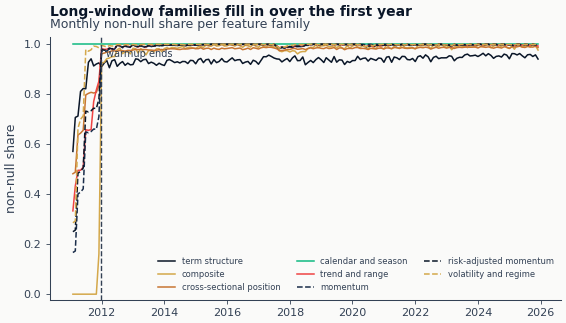

In [19]:
plot_coverage_through_time(
    coverage,
    warmup_boundary=WARMUP_END,
    title="Long-window families fill in over the first year",
    subtitle="Monthly non-null share per feature family",
    alt=(
        "Line chart of non-null share by feature family by month, on a y-axis running from "
        "zero to one. The composite and cross-sectional families sit at zero until the end of "
        "2011 and then jump to near one at the marked warmup boundary. Every other family "
        "rises through 2011 and all of them then sit between about 0.9 and one for the rest of "
        "the sample. Term structure is the lowest and the only visibly ragged one, running "
        "around 0.94; the calendar family sits flat at one and the rest are close to it."
    ),
)

### F4. The timing contract

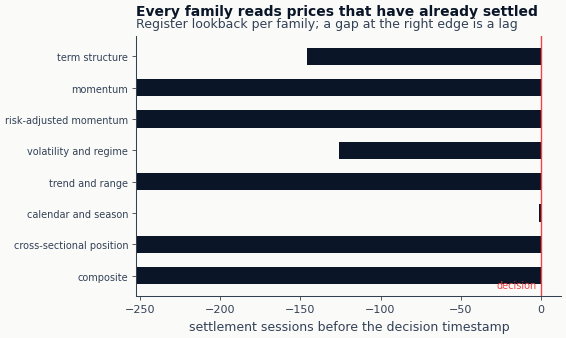

In [20]:
plot_timing_contract(
    FAMILIES,
    bar_unit="settlement sessions",
    title="Every family reads prices that have already settled",
    subtitle="Register lookback per family; a gap at the right edge is a lag",
    alt=(
        "Horizontal bars, one per feature family, each extending leftward from the decision "
        "line by that family's lookback: 252 sessions for momentum, risk-adjusted momentum, "
        "trend and range, the cross-sectional percentiles and the composites, 146 for term "
        "structure, 126 for volatility and one for the calendar family. Every bar reaches the "
        "decision line, so none of them is drawn with a gap at its right-hand end."
    ),
)

## F. What the features look like

Four properties decide whether this matrix can be used at all: the scale each feature arrives on,
whether the cross-section disagrees enough to rank on, how much of the set is one ordering under
several names, and how long a value lasts. `05_evaluation` is where the matrix is tested fold by
fold for whether any of it predicts.

### F2. Feature distributions

The carry family is shown on the scale a reader would judge it: the raw spread, its smoothed
level, the change in it, how far it sits from its own history, and its two rankings. The same
quantity looks completely different in level and in percentile form, which is the point of
carrying both.

The percentiles are combed rather than smooth, and that is worth reading rather than dismissing.
A percentile taken over thirty products can only land on thirty values, so its histogram is a
row of teeth wherever the cross-section is small - and the within-sector ranking, taken over
three to six products, is a handful of teeth and nothing between them.

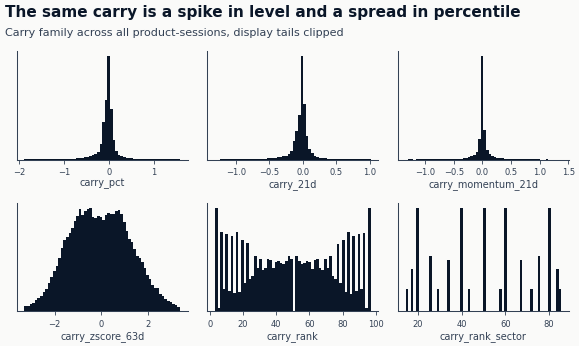

In [21]:
plot_feature_distributions(
    features,
    [
        "carry_pct",
        "carry_21d",
        "carry_momentum_21d",
        "carry_zscore_63d",
        "carry_rank",
        "carry_rank_sector",
    ],
    title="The same carry is a spike in level and a spread in percentile",
    subtitle="Carry family across all product-sessions, display tails clipped",
    alt=(
        "Six histograms in two rows. The three level features - the raw carry spread, its "
        "smoothed version and its one-month change - are all sharply peaked at zero with long "
        "thin tails to either side. The 63-session z-score below them is a broad, roughly "
        "symmetric bell spanning about minus three to three. The two percentiles spread across "
        "their whole range instead, both of them combed into discrete teeth: the unconditional "
        "ranking has teeth across the full zero-to-one-hundred axis with the tallest at either "
        "end, and the within-sector one is reduced to a few tall spikes because a sector holds "
        "only three to six products to rank within."
    ),
)

### F3. Cross-sectional dispersion through time

A cross-sectional strategy needs the cross-section to disagree. On a date where the band narrows
to nothing there is nothing to rank, whatever the average level of carry. This reads the
front-month slice cut in Section E.

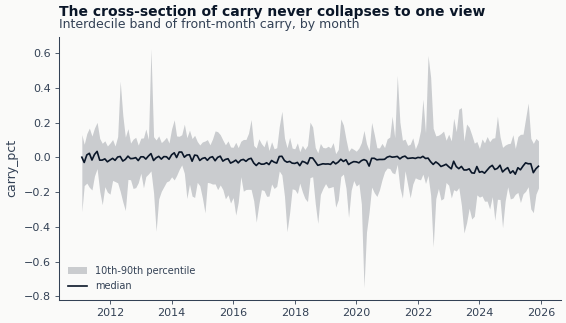

In [22]:
plot_cross_sectional_dispersion(
    front,
    "carry_pct",
    every="1mo",
    title="The cross-section of carry never collapses to one view",
    subtitle="Interdecile band of front-month carry, by month",
    alt=(
        "Shaded band of the 10th to 90th percentile of front-month carry by month, with the "
        "median drawn through it. The median stays close to zero throughout. The band spans "
        "roughly minus 0.15 to plus 0.15 in calm periods and never narrows to nothing; it "
        "reaches below minus 0.7 in 2020 and widens again through 2021 and 2022."
    ),
)

### F5. Redundancy structure

Features are ranked before they are correlated, so the correlation is Spearman's $\rho_s$ and
the question it answers is whether two columns carry the same *ordering* rather than the same
values. Clustering on the distance $1 - |\rho_s|$ therefore groups columns that order the
universe alike, whatever the sign of the relation. The cut is a screen and not a proof: a
cluster forming below it is a place to look for columns whose coefficients a linear model will
estimate against each other rather than independently. Average linkage joins on the mean
distance, so a cluster can also hold a pair that correlates less than the cut on its own.

This states the structure and takes no feature out of the matrix. `05_evaluation` tests each
column against the label on its own, and separately lists the pairs correlating above the same
cut. Both lists are printed there, and reading one against the other is what tells you whether
several columns surviving its screen are several findings or one finding under several names.

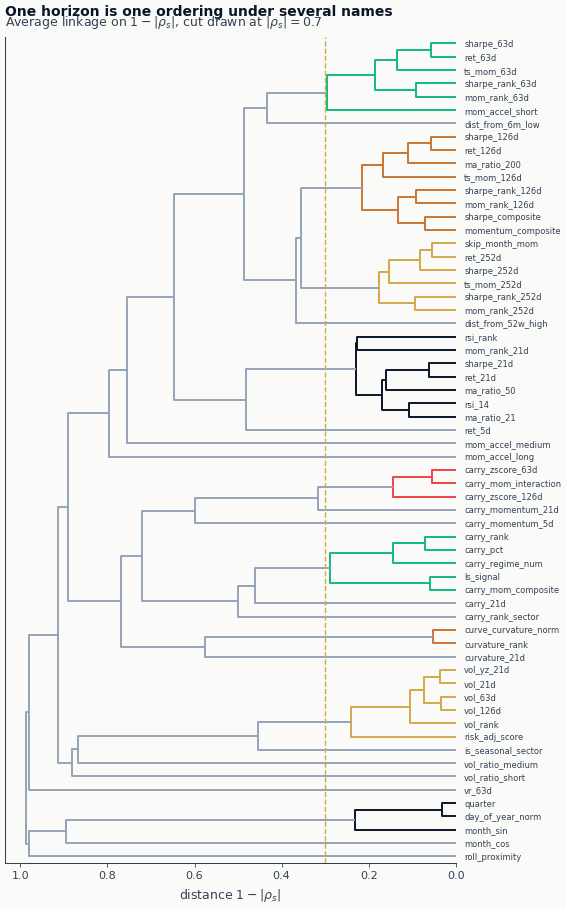

In [23]:
CUT = 0.7
clusters = plot_redundancy_clusters(
    features,
    feature_cols,
    cut=CUT,
    title="One horizon is one ordering under several names",
    subtitle=r"Average linkage on $1 - |\rho_s|$, cut drawn at $|\rho_s| = 0.7$",
    alt=(
        "Dendrogram of every feature in the matrix. The clusters below the cut are horizon "
        "blocks that mix levels with their percentiles: the three-month return, its Sharpe, its "
        "sign and both of their percentiles join at very small distances, and the same happens "
        "at the six-month horizon, at the one-year horizon, and again for the carry level with "
        "its rank, its regime indicator and the long-short signal. The volatility windows form "
        "one cluster with the volatility percentile. The calendar features and the variance "
        "ratio attach only near the root, sharing an ordering with nothing else."
    ),
)

Cutting the redundancy tree at $|\rho_s| = 0.7$ leaves **25 clusters** across the **62** columns,
so well over half the matrix repeats an ordering another column already carries.

In [24]:
print(f"{len(set(clusters.values()))} clusters over {len(feature_cols)} features at cut {CUT}")

25 clusters over 62 features at cut 0.7


### F6. Persistence and rank stability

The left panel is the autocorrelation of the feature itself, not of the return, and it runs to
four decision cycles - four weeks, on this strategy's Friday-close rebalance. A feature whose
value has decayed before the next rebalance cannot support that cadence, however well it
predicts on the day it is computed. It is estimated per product on pairs of dates exactly one
lag apart and summarized by the median over products, with a bootstrap interval over products: a
correlation pooled over every product-date pair would read high whenever products sit at
different levels, whether or not any one of them persists.

The right panel asks the same question of the ordering rather than the level, comparing the
cross-sectional ranking on one rebalance against the ranking on the next. Both panels read the
front-month slice, for the reason Section E gives.

The rebalance dates come from the same resolver the backtest uses, given this case study's
declared cadence and the sessions the panel actually holds, so the panels below are a statement
about the dates the strategy really acts on.

The resolver turns the cadence into real dates rather than counting days forward, so it is worth
seeing what `weekly_friday_close` comes out as: the last session of each week, which is Friday in
almost every week, Thursday where Friday is an exchange holiday, and whatever the final partial
week of the sample ends on. The weekday counts below are printed for that reason.

779 weekly_friday_close rebalances, 2011-02-04 to 2025-12-31
Friday 765, Thursday 13, Wednesday 1


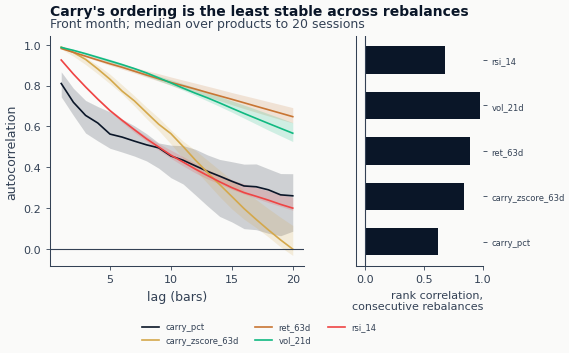

In [25]:
CADENCE = setup["decision"]["cadence"]
DECISION_DATES = resolve_rebalance_timestamps(
    features["timestamp"], CADENCE, calendar=setup["evaluation"]["calendar"]
).to_list()
by_weekday = (
    pl.Series(DECISION_DATES).dt.to_string("%A").value_counts().sort("count", descending=True)
)
print(f"{len(DECISION_DATES):,} {CADENCE} rebalances, {DECISION_DATES[0]} to {DECISION_DATES[-1]}")
print(", ".join(f"{r['']} {r['count']}" for r in by_weekday.iter_rows(named=True)))

plot_persistence(
    front,
    ["carry_pct", "carry_zscore_63d", "ret_63d", "vol_21d", "rsi_14"],
    entity="product",
    max_lag=4 * DECISION_CYCLE,
    decision_dates=DECISION_DATES,
    title="Carry's ordering is the least stable across rebalances",
    subtitle=f"Front month; median over products to {4 * DECISION_CYCLE} sessions",
    alt=(
        "Two panels. On the left, autocorrelation against lag: four of the five start near one "
        "and the raw carry starts near 0.8, and all of them decay over twenty sessions. The "
        "three-month return and the one-month volatility fall slowest, to roughly 0.6, while the "
        "carry z-score falls fastest and reaches zero; the raw carry drops steeply over the first "
        "ten sessions and then flattens near 0.27, and the oscillator ends near 0.2. The "
        "bootstrap ribbon is widest around the raw carry and around the carry z-score as it "
        "approaches zero, and narrow elsewhere. On the right, the cross-sectional rank "
        "correlation between consecutive weekly "
        "rebalances puts the one-month volatility highest at nearly one and the raw carry lowest "
        "at roughly 0.6, with the oscillator, the three-month return and the carry z-score "
        "between."
    ),
)

### F7. Two signals through time

Two of the families side by side, sampled on the rebalance dates rather than on every session,
because a value the strategy never reads is not a value it can act on. Crude oil and the S&P 500
e-mini are drawn because they sit at opposite ends of the roll cycle, monthly against quarterly,
and a second pair would only add lines over the same shape.

The carry z-score is a distance from a product's own recent history, so it is bounded and pulled
back to zero; the momentum composite is a standing among the other 29 products, so it can sit at
one end of the range for years. A signal that oscillates and a signal that trends need different
holding periods, which is why both are in the matrix.

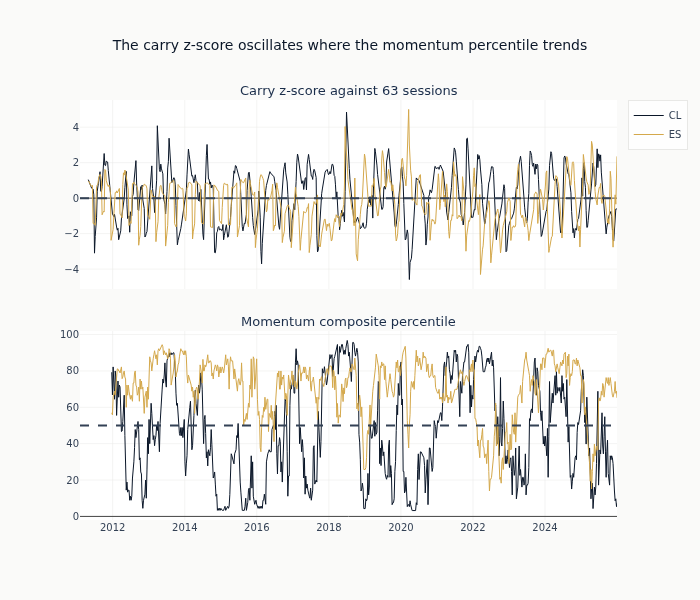

In [26]:
KEY_PRODUCTS = {"CL": COLORS["blue"], "ES": COLORS["amber"]}
decisions = front.filter(pl.col("timestamp").is_in(DECISION_DATES)).sort("timestamp")
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Carry z-score against 63 sessions", "Momentum composite percentile"],
    vertical_spacing=0.1,
)
for product, color in KEY_PRODUCTS.items():
    series = decisions.filter(pl.col("product") == product)
    for row, column in ((1, "carry_zscore_63d"), (2, "momentum_composite")):
        fig.add_trace(
            go.Scatter(
                x=series["timestamp"].to_list(),
                y=series[column].to_list(),
                name=product,
                line=dict(width=1, color=color),
                showlegend=row == 1,
            ),
            row=row,
            col=1,
        )
fig.add_hline(y=0, line_dash="dash", line_color=COLORS["neutral"], row=1, col=1)
fig.add_hline(y=50, line_dash="dash", line_color=COLORS["neutral"], row=2, col=1)
fig.update_layout(
    height=600, title_text="The carry z-score oscillates where the momentum percentile trends"
)
style_subplot_titles(fig)
fig.show()

### F8. The curve on one date

What carry looks like across the universe at a single decision, which is the object the strategy
actually ranks. The date is the most recent **rebalance** on which all 30 products quoted both of
the contracts carry is measured between, so it is a cross-section a decision was really taken
over rather than an arbitrary session or a partial universe.

The colours come from the regime band declared in the configuration. A product counts as
backwardation only once its carry clears that band, and as contango only once it falls below
minus it; everything between is called flat, which is what keeps a curve quoted a tick apart out
of both baskets. The band is printed with the snapshot below, on the same scale as the axis. The
vertical scale itself is what a single ranking has to absorb.

Friday 2025-12-19, regime band +/-0.01 on the carry scale
contango 14, backwardation 13, flat 3


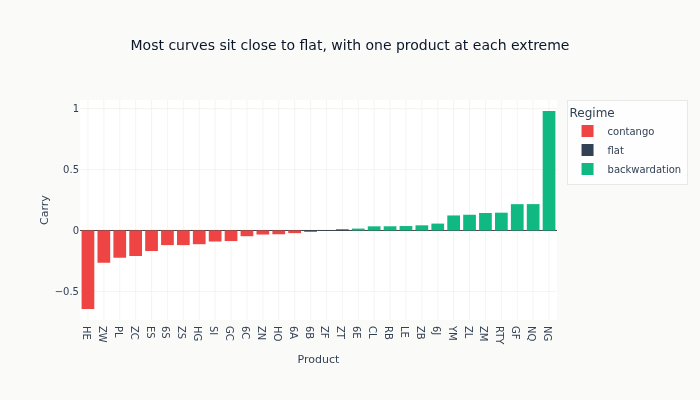

In [27]:
REGIME = {1: "backwardation", 0: "flat", -1: "contango"}
quoted = (
    front.filter(pl.col("timestamp").is_in(DECISION_DATES))
    .group_by("timestamp")
    .agg(pl.col("carry_pct").is_not_null().sum().alias("n"))
)
snapshot_date = quoted.filter(pl.col("n") == front["product"].n_unique())["timestamp"].max()
snapshot = front.filter(pl.col("timestamp") == snapshot_date).with_columns(
    pl.col("carry_regime_num").replace_strict(REGIME).alias("Regime")
)
counts = snapshot["Regime"].value_counts().sort("count", descending=True)
print(
    f"{snapshot_date:%A %Y-%m-%d}, regime band +/-{LEVEL['carry_regime_band']} on the carry scale"
)
print(", ".join(f"{r['Regime']} {r['count']}" for r in counts.iter_rows(named=True)))

fig = px.bar(
    snapshot.sort("carry_pct").to_pandas(),
    x="product",
    y="carry_pct",
    color="Regime",
    color_discrete_map={
        "backwardation": COLORS["positive"],
        "flat": COLORS["neutral"],
        "contango": COLORS["negative"],
    },
    title="Most curves sit close to flat, with one product at each extreme",
    labels={"carry_pct": "Carry", "product": "Product"},
)
fig.update_layout(height=400)
fig.show()

## G. Emit

The parquet is written with a sidecar recording the digest of its values, its row count and key
columns, and the digest of what it was built from. This stage reads no upstream case-study
artifact, so the sidecar records the loaded settlement panel alone, restricted to the columns and
window actually consumed - which is what answers "which market-data vintage produced these
values". The digest is computed over content rather than file bytes, so row order and parquet
metadata leave it alone and any feature value moves it. That is the property the registry's own
hashes lack: a feature-set *name* reaches the registry, a feature-set *value* does not.

[`05_evaluation`](05_evaluation.ipynb) opens the file directly and screens these columns fold by
fold for whether any of them predicts the label. The modelling notebooks from
[`06_linear`](06_linear.ipynb) onward reach it through `load_modeling_dataset`, which joins it to
the label parquet and to the model-based features and hands one training matrix to every
estimator, so that they are all fitted on the same rows.
[`12_model_analysis`](12_model_analysis.ipynb) opens it directly too, on the one path where the
gradient-boosting run left no saved booster to read importances out of: it then ranks these
columns by their correlation with the linear model's predictions instead.

In [28]:
record = write_artifact(
    features,
    FEATURES_DIR / "financial.parquet",
    keys=PANEL_KEY,
    written_by="case_studies/cme_futures/03_financial_features.py",
    inputs={"load_cme_futures": value_digest(bars.select([*PANEL_KEY, *PRICES, "volume"]))},
)
print(f"Wrote {display_path(FEATURES_DIR / 'financial.parquet')}, digest {record['digest']}")

Wrote /home/stefan/ml4t/code/case_studies/cme_futures/features/financial.parquet, digest 72074c42fc2dfdd8


## Key takeaways

- **State the timing contract before writing the feature.** The register fixes each family's
  lookback and lag in the configuration, and the warmup assertion, the timing figure and the
  review a reader can run all read those numbers rather than re-deriving them from the code.
- **Match the price series to the question.** A spread between two tenors needs the settled
  prices and a return needs the roll-adjusted ones. Using one series for both measures roll
  history and calls it curve shape.
- **Rank inside the frame a decision is taken over.** For a term structure that is the date *and*
  the contract position; a percentile taken across positions compares two different instruments.
- **Test the seal by construction, not by inspection.** Rebuilding the panel with later dates
  withheld and comparing values catches any transform that fits across the sample, including the
  ones nobody thought to flag.
- **Read the matrix before modelling it.** Distribution, dispersion, redundancy and decay each
  rule out a use: a feature with no cross-sectional spread cannot rank, and one whose ordering
  decays inside the rebalance cycle cannot be traded at that cadence.

### Known limitations

- Carry is measured between the first two contract positions, and how far apart in time those
  two sit depends on the product's own listing cycle: one month for the four energy curves,
  three for the equity-index, Treasury and currency contracts, and anywhere from one to three
  for the metals, grains and livestock, whose cycles are irregular and whose gap therefore
  changes within the year. The construction applies the same factor of twelve to all of them, so
  the carry level is a per-year rate only for the monthly cycles and is not comparable
  between sectors - which is the reason the within-sector percentile is carried beside the
  unconditional one. Making the level comparable would need each contract's own expiry date,
  which the continuous panel does not carry.
- The roll-week flag is a calendar approximation, not a contract's own expiry. Products on
  quarterly cycles do not roll every month, and the flag marks the last week of every month for
  all of them.
- Curvature needs a third tenor, so it is null wherever the panel carries only two.
- Every feature here is a rule written in advance. `04_model_based_features` adds the features
  that are themselves model outputs, where the rule is estimated from the data.